In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Path to dataset files: /kaggle/input/customer-segmentation-tutorial-in-python


In [ ]:
import os
print(os.listdir(path))

['Mall_Customers.csv']


In [ ]:
import pandas as pd
df=pd.read_csv(path + "/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
print(df.shape)
print(df.info())

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [ ]:
print(df.dtypes)
print(df.nunique())

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object
CustomerID                200
Gender                      2
Age                        51
Annual Income (k$)         64
Spending Score (1-100)     84
dtype: int64


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.info()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


(200, 5)

In [ ]:
df.select_dtypes(include=['object'])


,Gender
0,Male
1,Male
2,Female
3,Female
4,Female
...,...
195,Female
196,Female
197,Male
198,Male


In [ ]:
df.select_dtypes(include=['int64','float64'])

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40
...,...,...,...,...
195,196,35,120,79
196,197,45,126,28
197,198,32,126,74
198,199,32,137,18


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


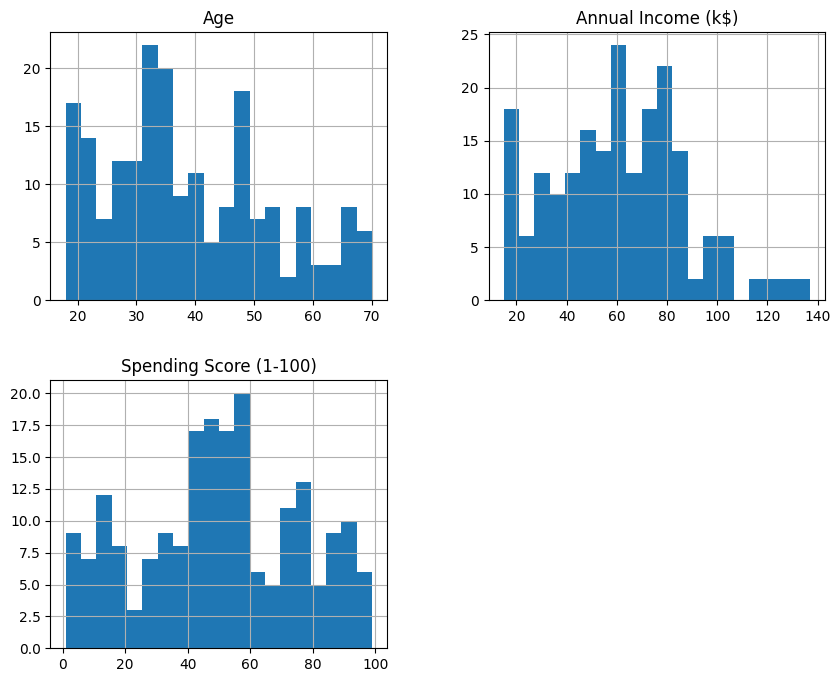

In [ ]:
import matplotlib.pyplot as plt
df.drop(columns='CustomerID').hist(figsize=(10,8) , bins=20)
plt.show()

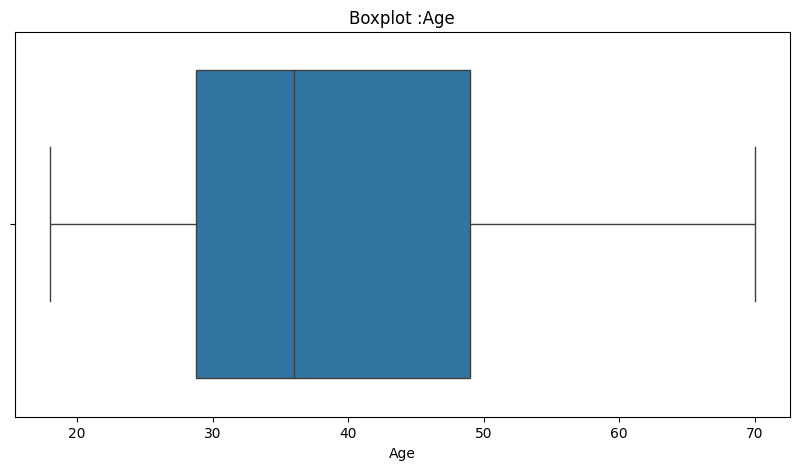

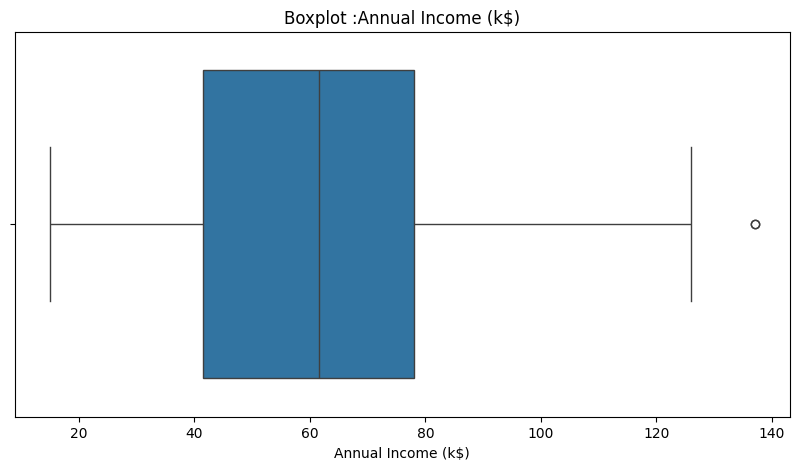

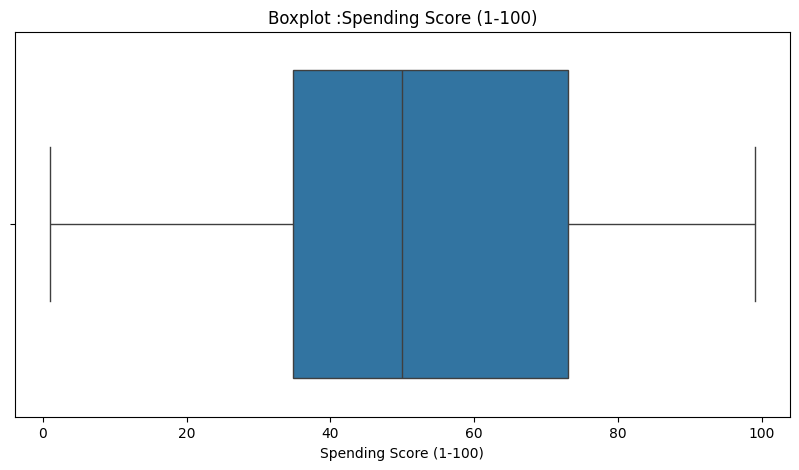

In [ ]:
import seaborn as sns
for col in['Age','Annual Income (k$)' , 'Spending Score (1-100)' ]:
  plt.figure(figsize=(10,5))
  sns.boxplot(x=df[col])
  plt.title(f"Boxplot :{col}")
  plt.show()

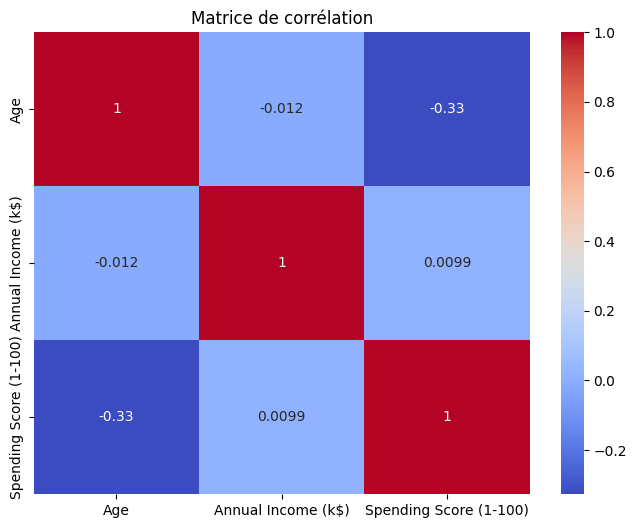

In [ ]:
plt.figure(figsize=(8,6))
corr=df[['Age','Annual Income (k$)' , 'Spending Score (1-100)']].corr()
sns.heatmap(corr, annot=True , cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

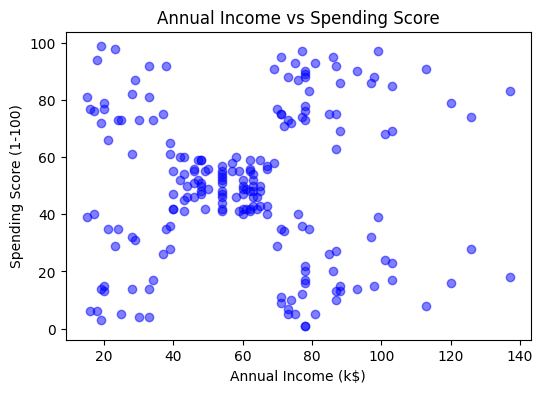

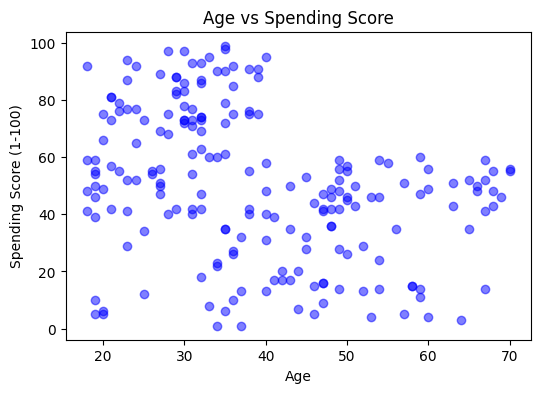

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(x=df['Annual Income (k$)'] , y=df['Spending Score (1-100)'] ,alpha=0.5 , color='blue')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(x=df['Age'] , y=df['Spending Score (1-100)'] ,alpha=0.5 , color='blue')
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.title("Age vs Spending Score")
plt.show()

In [ ]:

for col in ['Age','Annual Income (k$)' , 'Spending Score (1-100)']:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  outlier=df[(df[col] <Q1-1.5*IQR) | (df[col] >Q3+1.5*IQR)]
  print(f"Outliers for {col}: {len(outlier)}")



Outliers for Age: 0
Outliers for Annual Income (k$): 2
Outliers for Spending Score (1-100): 0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Gender_enc']=le.fit_transform(df['Gender'])
df.drop(columns='Gender' , inplace=True)
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_enc
0,1,19,15,39,1
1,2,21,15,81,1
2,3,20,16,6,0
3,4,23,16,77,0
4,5,31,17,40,0


In [ ]:
from sklearn.preprocessing import StandardScaler

f_2d=['Annual Income (k$)','Spending Score (1-100)']
f_3d=['Age','Annual Income (k$)','Spending Score (1-100)']
scaler_2d=StandardScaler()
scaler_3d=StandardScaler()
x_2d=scaler_2d.fit_transform(df[f_2d])
x_3d=scaler_3d.fit_transform(df[f_3d])
print(x_2d.shape)
print(x_3d.shape)
print(pd.DataFrame(x_2d , columns=['Annual Income (k$)','Spending Score (1-100)']).describe().round(3))


(200, 2)
(200, 3)
       Annual Income (k$)  Spending Score (1-100)
count             200.000                 200.000
mean               -0.000                  -0.000
std                 1.003                   1.003
min                -1.739                  -1.910
25%                -0.728                  -0.600
50%                 0.036                  -0.008
75%                 0.666                   0.885
max                 2.918                   1.894


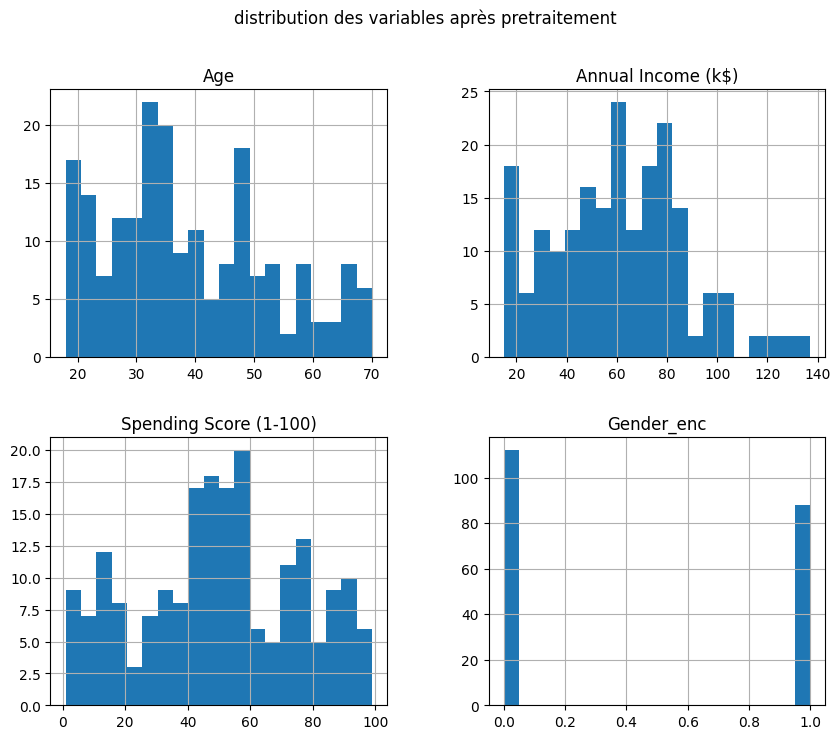

In [ ]:
import matplotlib.pyplot as plt
colsa=['Age','Annual Income (k$)' , 'Spending Score (1-100)','Gender_enc']

df[colsa].hist(figsize=(10,8) , bins=20)
plt.suptitle("distribution des variables après pretraitement")
plt.show()

/tmp/ipykernel_2827/434006275.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([df["Annual Income (k$)"], df["Spending Score (1-100)"]],
/tmp/ipykernel_2827/434006275.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([x_2d[:, 0], x_2d[:, 1]],


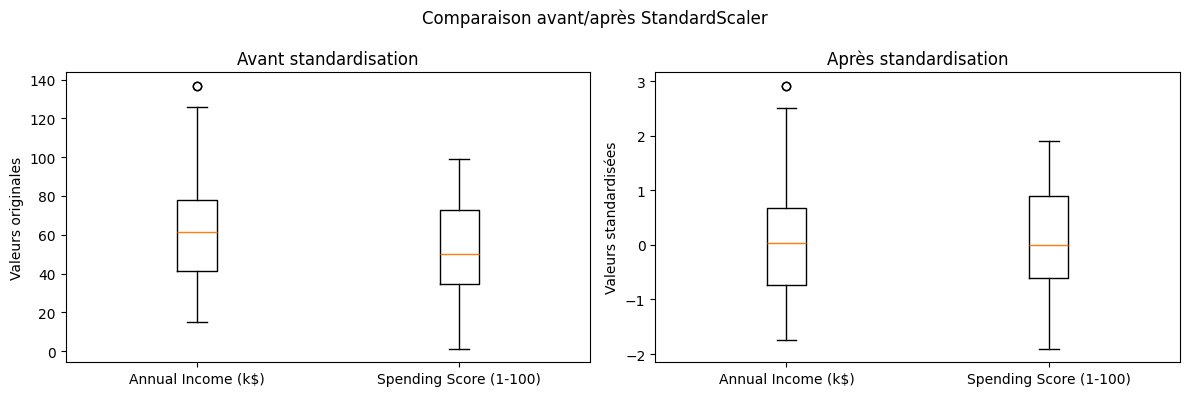

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].boxplot([df["Annual Income (k$)"], df["Spending Score (1-100)"]],
                labels=["Annual Income (k$)", "Spending Score (1-100)"])
axes[0].set_title("Avant standardisation")
axes[0].set_ylabel("Valeurs originales")


axes[1].boxplot([x_2d[:, 0], x_2d[:, 1]],
                labels=["Annual Income (k$)", "Spending Score (1-100)"])
axes[1].set_title("Après standardisation")
axes[1].set_ylabel("Valeurs standardisées")

plt.suptitle("Comparaison avant/après StandardScaler")
plt.tight_layout()
plt.savefig("avant_apres_standardisation.png", bbox_inches="tight")
plt.show()

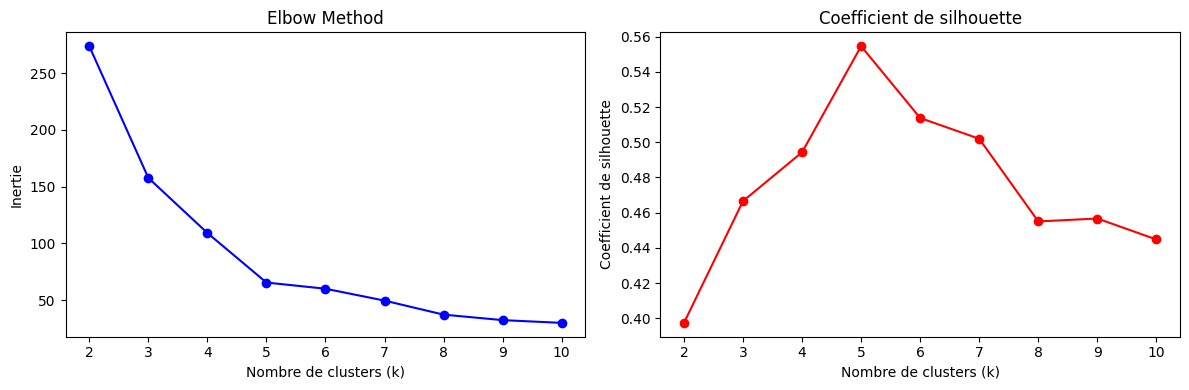

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score , davies_bouldin_score, calinski_harabasz_score

inertie =[]
silhouette=[]
k_range=range(2,11)

for k in k_range:
  km= KMeans(n_clusters=k , random_state=42)
  km.fit(x_2d)
  inertie.append(km.inertia_)
  silhouette.append(silhouette_score(x_2d,km.labels_))

fig, (axe1, axe2) = plt.subplots(1, 2, figsize=(12, 4))


axe1.plot(k_range, inertie, 'bo-')
axe1.set_xlabel('Nombre de clusters (k)')
axe1.set_ylabel('Inertie')
axe1.set_title('Elbow Method')

axe2.plot(k_range, silhouette, 'ro-')
axe2.set_xlabel('Nombre de clusters (k)')
axe2.set_ylabel('Coefficient de silhouette')
axe2.set_title('Coefficient de silhouette')

plt.tight_layout()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(x_2d )
labels_kmeans = kmeans.labels_
centres =kmeans.cluster_centers_
print(centres)

[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


In [ ]:
sil = silhouette_score(x_2d, labels_kmeans)
dbi = davies_bouldin_score(x_2d, labels_kmeans)
ch = calinski_harabasz_score(x_2d, labels_kmeans)
print("Coefficient de silhouette :", sil) #proche de 1 l'echelle [-1 ,1]
print("Davies-Bouldin Index :", dbi) #proche de 0  L'échelle est [0, +∞]
print("Calinski-Harabasz Index :", ch) #elve bon

Coefficient de silhouette : 0.5546571631111091
Davies-Bouldin Index : 0.5722356162263352
Calinski-Harabasz Index : 248.64932001536357


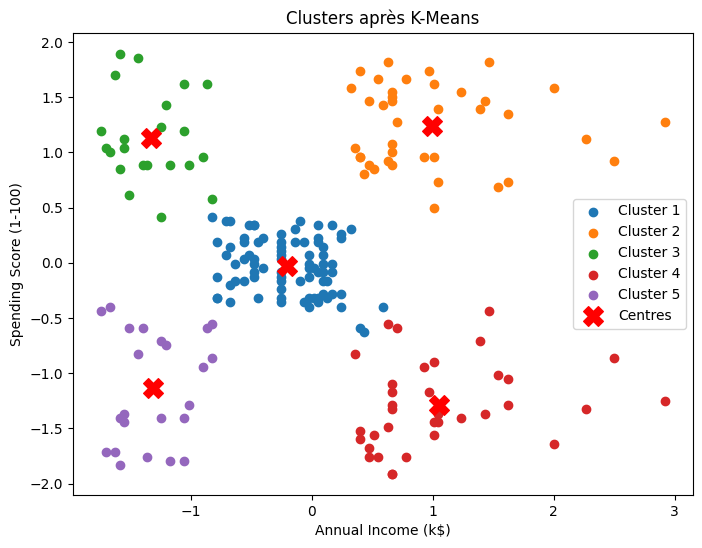

In [ ]:
plt.figure(figsize=(8,6))

for cluster in range(5):
  mask = labels_kmeans == cluster
  plt.scatter(x_2d[mask, 0], x_2d[mask, 1], label=f"Cluster {cluster+1}")
plt.scatter(centres[:, 0], centres[:, 1], marker='X', s=200, c='red', label='Centres')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Clusters après K-Means")
plt.legend()
plt.show()

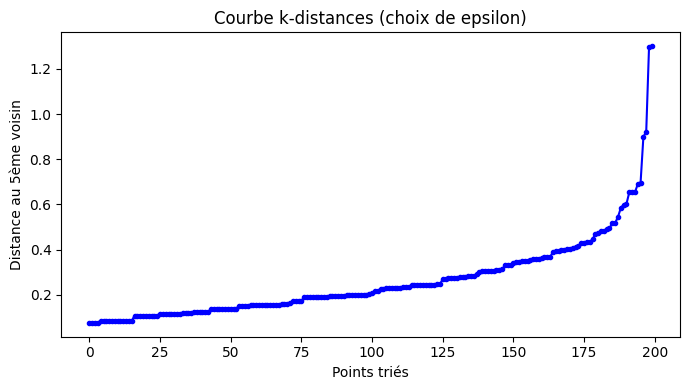

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np


from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(x_2d)
distances, indices = neighbors.kneighbors(x_2d)


distances_5 = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(7, 4))
plt.plot(distances_5, 'bo-', markersize=3)
plt.xlabel('Points triés')
plt.ylabel('Distance au 5ème voisin')
plt.title('Courbe k-distances (choix de epsilon)')
plt.tight_layout()
plt.show()

In [ ]:

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit(x_2d)

labels_dbscan = dbscan.labels_


n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_bruit    = list(labels_dbscan).count(-1)

print(f"Nombre de clusters trouvés : {n_clusters}")
print(f"Nombre de points bruit     : {n_bruit}")

Nombre de clusters trouvés : 2
Nombre de points bruit     : 8


In [ ]:
if n_clusters > 1:

    mask_valide = labels_dbscan != -1
    sil_db = silhouette_score(x_2d[mask_valide], labels_dbscan[mask_valide])
    dbi_db = davies_bouldin_score(x_2d[mask_valide], labels_dbscan[mask_valide])
    chi_db = calinski_harabasz_score(x_2d[mask_valide], labels_dbscan[mask_valide])

    print(f"Silhouette Score     : {sil_db:.4f}")
    print(f"Davies-Bouldin Index : {dbi_db:.4f}")
    print(f"Calinski-Harabasz    : {chi_db:.4f}")
else:
    print("DBSCAN n'a trouvé qu'un seul cluster → métriques non calculables")

Silhouette Score     : 0.3876
Davies-Bouldin Index : 0.7889
Calinski-Harabasz    : 85.3897


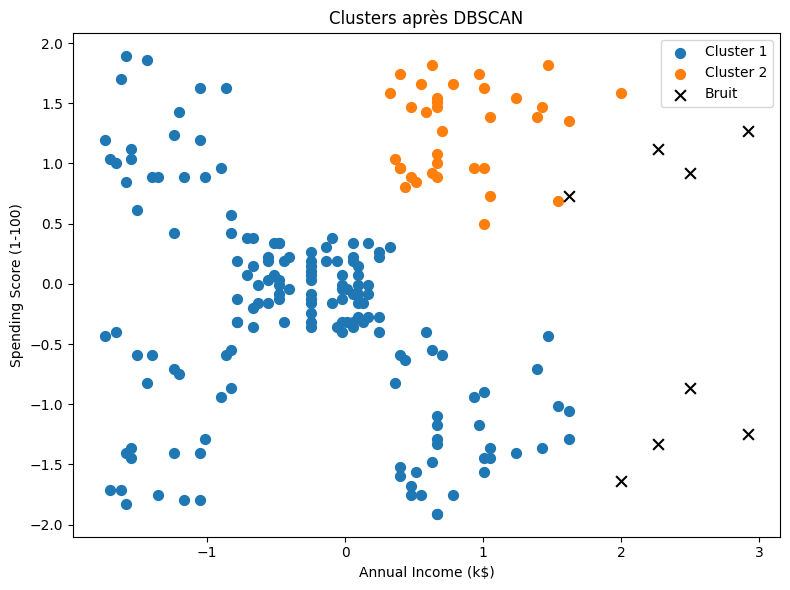

In [ ]:
plt.figure(figsize=(8, 6))

unique_labels = set(labels_dbscan)
for cluster in unique_labels:
    mask = labels_dbscan == cluster
    if cluster == -1:
        plt.scatter(x_2d[mask, 0], x_2d[mask, 1],
                    c='black', marker='x', s=60, label='Bruit')
    else:
        plt.scatter(x_2d[mask, 0], x_2d[mask, 1],
                    label=f'Cluster {cluster+1}', s=50)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Clusters après DBSCAN')
plt.legend()
plt.tight_layout()
plt.show()

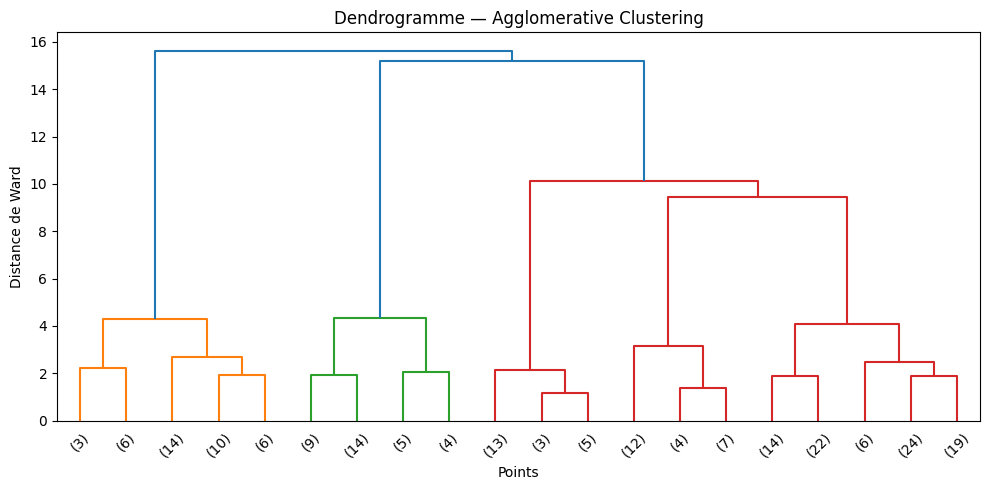

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
linkage_matrix = linkage(x_2d, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=10)
plt.xlabel('Points')
plt.ylabel('Distance de Ward')
plt.title('Dendrogramme — Agglomerative Clustering')
plt.tight_layout()
plt.show()

In [ ]:
agglo = AgglomerativeClustering(n_clusters=5, linkage='ward')
agglo.fit(x_2d)

labels_agglo = agglo.labels_

print(f"Nombre de clusters : {len(set(labels_agglo))}")
print(f"Répartition        : {dict(zip(*np.unique(labels_agglo, return_counts=True)))}")

Nombre de clusters : 5
Répartition        : {np.int64(0): np.int64(32), np.int64(1): np.int64(39), np.int64(2): np.int64(85), np.int64(3): np.int64(21), np.int64(4): np.int64(23)}


In [ ]:
sil_ag = silhouette_score(x_2d, labels_agglo)
dbi_ag = davies_bouldin_score(x_2d, labels_agglo)
chi_ag = calinski_harabasz_score(x_2d, labels_agglo)

print(f"Silhouette Score     : {sil_ag:.4f}")
print(f"Davies-Bouldin Index : {dbi_ag:.4f}")
print(f"Calinski-Harabasz    : {chi_ag:.4f}")

Silhouette Score     : 0.5538
Davies-Bouldin Index : 0.5779
Calinski-Harabasz    : 244.4103


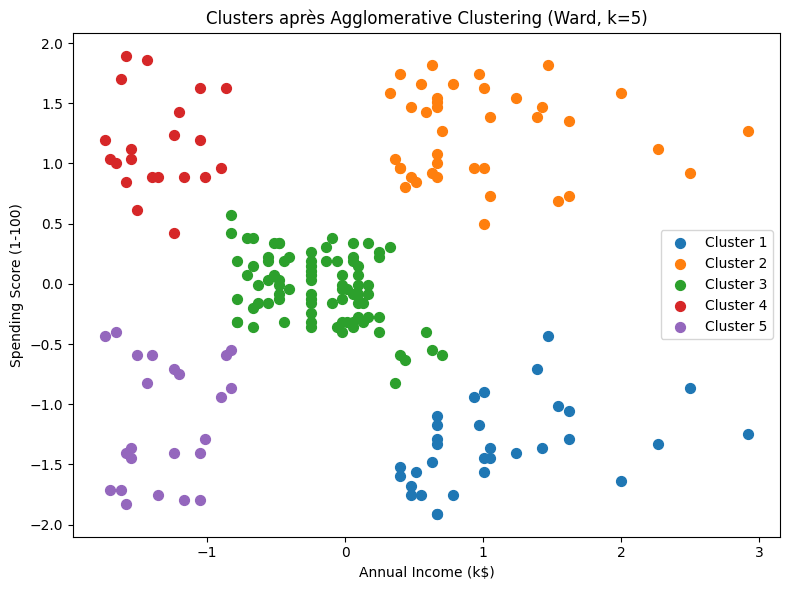

In [ ]:
plt.figure(figsize=(8, 6))

for cluster in range(5):
    mask = labels_agglo == cluster
    plt.scatter(x_2d[mask, 0], x_2d[mask, 1],
                label=f'Cluster {cluster+1}', s=50)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Clusters après Agglomerative Clustering (Ward, k=5)')
plt.legend()
plt.tight_layout()
plt.show()

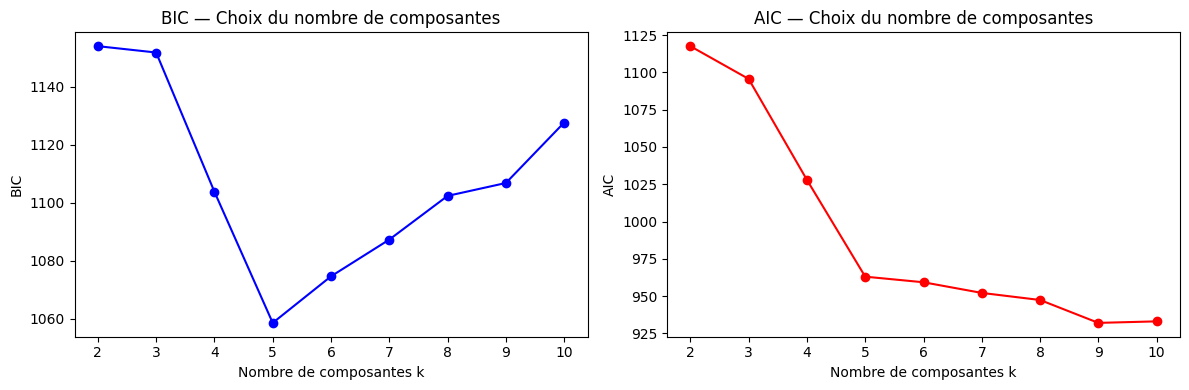

In [ ]:

from sklearn.mixture import GaussianMixture


bic_scores = []
aic_scores = []
k_range = range(2, 11)

for k in k_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(x_2d)
    bic_scores.append(gmm.bic(x_2d))
    aic_scores.append(gmm.aic(x_2d))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_range, bic_scores, 'bo-')
ax1.set_xlabel('Nombre de composantes k')
ax1.set_ylabel('BIC')
ax1.set_title('BIC — Choix du nombre de composantes')

ax2.plot(k_range, aic_scores, 'ro-')
ax2.set_xlabel('Nombre de composantes k')
ax2.set_ylabel('AIC')
ax2.set_title('AIC — Choix du nombre de composantes')

plt.tight_layout()
plt.show()

In [ ]:

gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=42)
gmm.fit(x_2d)

labels_gmm  = gmm.predict(x_2d)
proba_gmm   = gmm.predict_proba(x_2d)

print(f"Nombre de clusters : {len(set(labels_gmm))}")
print(f"Répartition        : {dict(zip(*np.unique(labels_gmm, return_counts=True)))}")
print(f"\nExemple probabilités (5 premiers points) :\n {proba_gmm[:5].round(3)}")

Nombre de clusters : 5
Répartition        : {np.int64(0): np.int64(84), np.int64(1): np.int64(39), np.int64(2): np.int64(21), np.int64(3): np.int64(33), np.int64(4): np.int64(23)}

Exemple probabilités (5 premiers points) :
 [[0.    0.    0.001 0.    0.999]
 [0.    0.    1.    0.    0.   ]
 [0.    0.    0.    0.    1.   ]
 [0.    0.    1.    0.    0.   ]
 [0.    0.    0.002 0.    0.998]]


In [ ]:
sil_gmm = silhouette_score(x_2d, labels_gmm)
dbi_gmm = davies_bouldin_score(x_2d, labels_gmm)
chi_gmm = calinski_harabasz_score(x_2d, labels_gmm)

print(f"Silhouette Score     : {sil_gmm:.4f}")
print(f"Davies-Bouldin Index : {dbi_gmm:.4f}")
print(f"Calinski-Harabasz    : {chi_gmm:.4f}")

Silhouette Score     : 0.5537
Davies-Bouldin Index : 0.5760
Calinski-Harabasz    : 244.9402


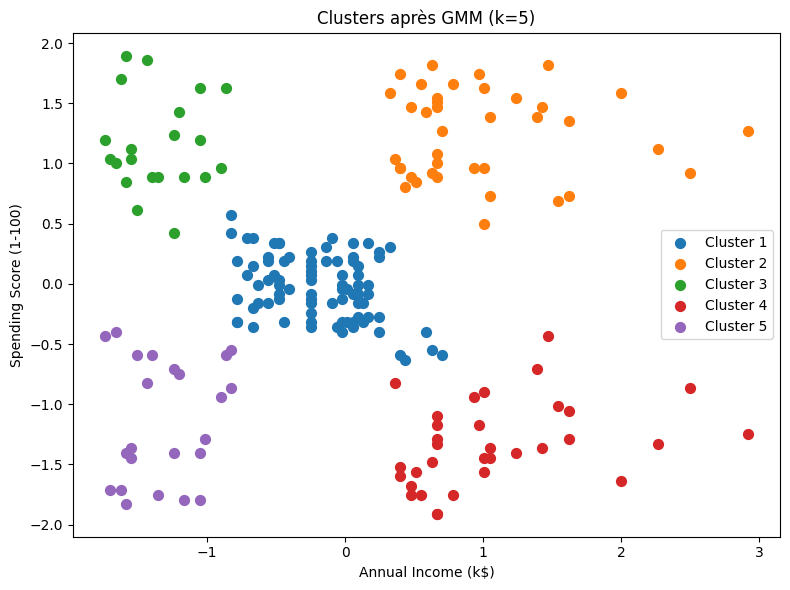

In [ ]:
plt.figure(figsize=(8, 6))

for cluster in range(5):
    mask = labels_gmm == cluster
    plt.scatter(x_2d[mask, 0], x_2d[mask, 1],
                label=f'Cluster {cluster+1}', s=50)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Clusters après GMM (k=5)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_2d)

print("Variance expliquée par composante :")
print(pca.explained_variance_ratio_.round(4))
print(f"Variance totale : {pca.explained_variance_ratio_.sum()*100:.2f}%")

Variance expliquée par composante :
[0.505 0.495]
Variance totale : 100.00%


In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(x_2d)

print("Shape t-SNE :", X_tsne.shape)

Shape t-SNE : (200, 2)


In [ ]:

labels_kmeans = kmeans.labels_
labels_agglo    = agglo.labels_
labels_gmm  = gmm.predict(x_2d)
labels_dbscan = dbscan.labels_

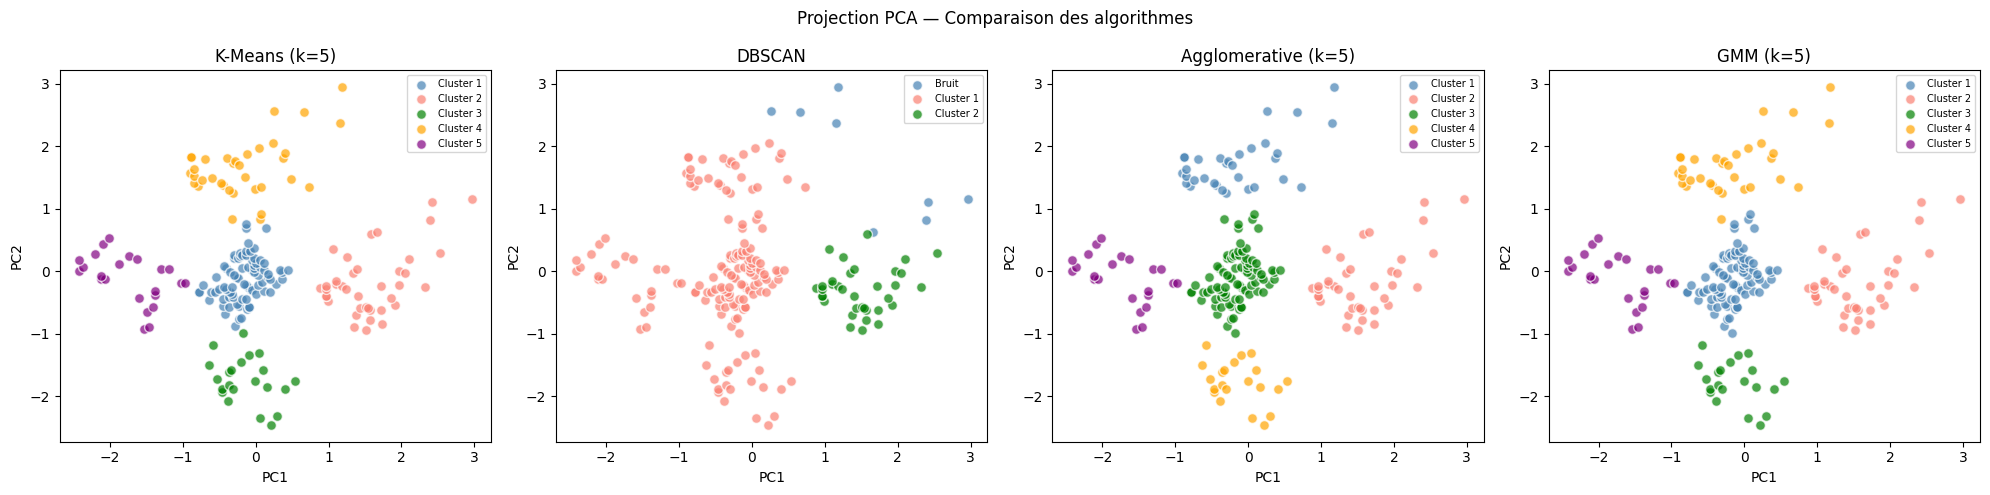

In [ ]:

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

tous_labels = [labels_kmeans, labels_dbscan, labels_agglo, labels_gmm]
titres      = ["K-Means (k=5)", "DBSCAN", "Agglomerative (k=5)", "GMM (k=5)"]
colors      = ["steelblue", "salmon", "green", "orange", "purple", "gray"]

for ax, labels, titre in zip(axes, tous_labels, titres):
    unique = sorted(set(labels))
    for i, cluster in enumerate(unique):
        mask = labels == cluster
        label = f"Bruit" if cluster == -1 else f"Cluster {cluster+1}"
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   label=label, color=colors[i],
                   alpha=0.7, edgecolors="white", s=50)
    ax.set_title(titre)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(fontsize=7)

plt.suptitle("Projection PCA — Comparaison des algorithmes")
plt.tight_layout()
plt.savefig("pca_tous_algos.png", bbox_inches="tight")
plt.show()

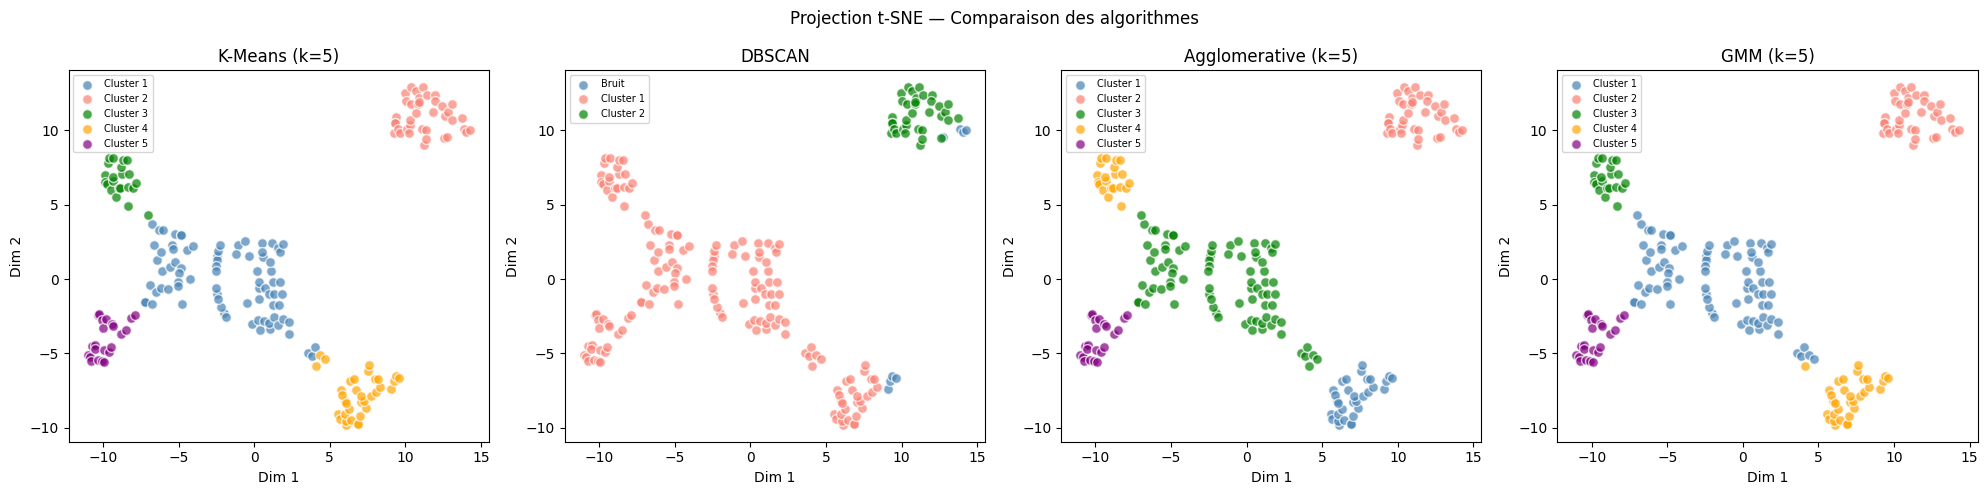

In [ ]:

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, labels, titre in zip(axes, tous_labels, titres):
    unique = sorted(set(labels))
    for i, cluster in enumerate(unique):
        mask = labels == cluster
        label = "Bruit" if cluster == -1 else f"Cluster {cluster+1}"
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   label=label, color=colors[i],
                   alpha=0.7, edgecolors="white", s=50)
    ax.set_title(titre)
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    ax.legend(fontsize=7)

plt.suptitle("Projection t-SNE — Comparaison des algorithmes")
plt.tight_layout()
plt.savefig("tsne_tous_algos.png", bbox_inches="tight")
plt.show()

In [ ]:

resultats = []

for labels, nom in zip(tous_labels, titres):
    mask = labels != -1
    if mask.sum() > 1 and len(set(labels[mask])) > 1:
        sil = silhouette_score(x_2d[mask], labels[mask])
        dbi = davies_bouldin_score(x_2d[mask], labels[mask])
        chi = calinski_harabasz_score(x_2d[mask], labels[mask])
    else:
        sil, dbi, chi = None, None, None
    resultats.append([nom, sil, dbi, chi])

df_resultats = pd.DataFrame(resultats,
               columns=["Algorithme", "Silhouette ",
                        "Davies-Bouldin ", "Calinski-Harabasz ↑"])
print(df_resultats.round(4))

            Algorithme  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
0        K-Means (k=5)        0.5547            0.5722             248.6493
1               DBSCAN        0.3876            0.7889              85.3897
2  Agglomerative (k=5)        0.5538            0.5779             244.4103
3            GMM (k=5)        0.5537            0.5760             244.9402


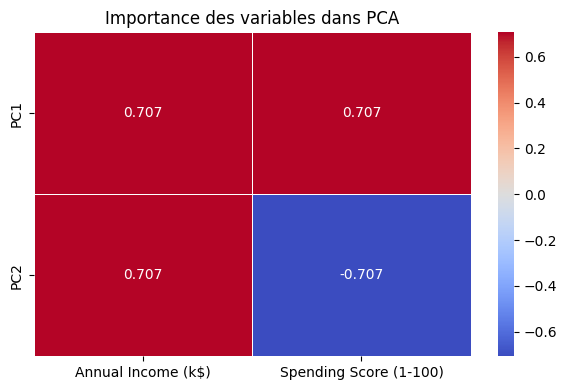


Variance expliquée :
PC1 : 50.50%
PC2 : 49.50%


In [ ]:
plt.figure(figsize=(6, 4))
composantes = pd.DataFrame(pca.components_,
              columns=["Annual Income (k$)", "Spending Score (1-100)"],
              index=["PC1", "PC2"])
sns.heatmap(composantes, annot=True, cmap="coolwarm",
            fmt=".3f", linewidths=0.5)
plt.title("Importance des variables dans PCA")
plt.tight_layout()
plt.savefig("pca_importance.png", bbox_inches="tight")
plt.show()

print("\nVariance expliquée :")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1} : {v*100:.2f}%")

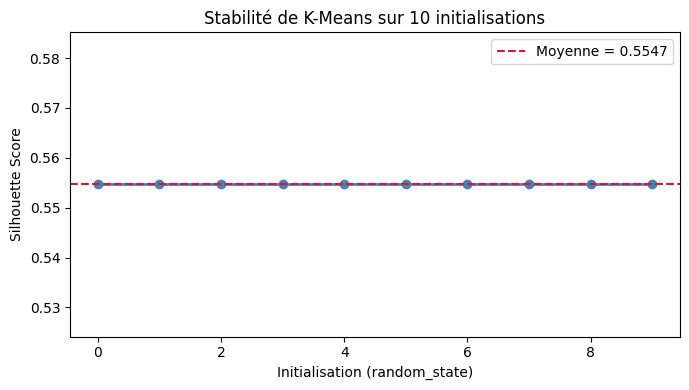

Silhouette moyen  : 0.5547
Écart-type        : 0.0000
Min               : 0.5547
Max               : 0.5547


In [ ]:
from sklearn.metrics import silhouette_score

scores = []
for seed in range(10):
    km = KMeans(n_clusters=5, init="k-means++",
                random_state=seed, n_init=10)
    km.fit(x_2d)
    scores.append(silhouette_score(x_2d, km.labels_))

plt.figure(figsize=(7, 4))
plt.plot(range(10), scores, marker="o",
         color="steelblue", linewidth=2)
plt.axhline(y=np.mean(scores), color="crimson",
            linestyle="--", label=f"Moyenne = {np.mean(scores):.4f}")
plt.xlabel("Initialisation (random_state)")
plt.ylabel("Silhouette Score")
plt.title("Stabilité de K-Means sur 10 initialisations")
plt.legend()
plt.tight_layout()
plt.savefig("stabilite.png", bbox_inches="tight")
plt.show()

print(f"Silhouette moyen  : {np.mean(scores):.4f}")
print(f"Écart-type        : {np.std(scores):.4f}")
print(f"Min               : {np.min(scores):.4f}")
print(f"Max               : {np.max(scores):.4f}")